In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import pandas as pd

import json

from matplotlib import transforms

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize
plt.rc('figure', titlesize=35)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "sans-serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

In [3]:
# Hyperparameters
gamma = 0.99
gamma_list = np.cumprod(np.repeat(gamma, 20))

In [3]:
def calc_cost(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)

    cost_list = []
    mean_list = []
    cost_list_total = []
    length = 100000
    sim_rounds = len(sim)
    num_sites = len(sim[0]['hist_cost'])
    
    for i in range(sim_rounds): # Sim
        cost_list_sim = []
        mean_list_sim = []
        for j in range(num_sites): # Site
            total_cost = 0
            total_time = 0
            for time, cost in sim[i]['hist_cost'][j]:
                # print(cost, cost * (gamma ** total_time), total_time)
                total_cost += cost * (gamma ** total_time)
                total_time += time

            total_cost /= ((1-gamma**(total_time+1))/(1-gamma))
            cost_list.append(-total_cost)
            cost_list_sim.append(-total_cost)
        temp_mean = np.abs(np.stack(sim[i]['mu_mean_hist']) - np.stack(sim[i]['mu_true']))
        if temp_mean.shape[0] < length:
            length = temp_mean.shape[0]
        
        mean_list.append(temp_mean)
        cost_list_total.append(np.mean(cost_list_sim))
    for i in range(sim_rounds):
        mean_list[i] = mean_list[i][:length]
    mean_list = np.mean(np.stack(mean_list), axis=0)
    
    return cost_list, cost_list_total, mean_list

In [4]:
collab_file_name = "simulation_results/50_5_12_0_collaborative_2024-12-26-20-34-44/result.json"
iso_file_name = "simulation_results/50_5_12_0_isolated_2024-12-26-17-53-11/result.json"
# ep_file_name = "simulation_results/50_5_10_0_EP_2024-09-29-16-25-48/result.json"
collab_lap_1_file_name = "simulation_results/50_5_12_1.0_collaborative_2024-12-26-18-09-33/result.json"
collab_lap_2_file_name = "simulation_results/50_5_12_3.0_collaborative_2024-12-26-20-42-12/result.json"

collab_cost, collab_cost_total, collab_mu = calc_cost(collab_file_name)
iso_cost, iso_cost_total, iso_mu = calc_cost(iso_file_name)
# ep_cost, ep_cost_total = calc_cost(ep_file_name)
collab_1_cost, collab_1_cost_total, collab_1_mu = calc_cost(collab_lap_1_file_name)
collab_2_cost, collab_2_cost_total, collab_2_mu = calc_cost(collab_lap_2_file_name)

FileNotFoundError: [Errno 2] No such file or directory: 'simulation_results/50_5_12_3.0_collaborative_2024-12-26-20-42-12/result.json'

In [ ]:
sim_accu = [collab_cost, collab_1_cost, collab_2_cost, iso_cost]
sim_accu_total = [collab_cost_total, collab_1_cost_total, collab_2_cost_total, iso_cost_total]
df_data = pd.DataFrame(columns=['collab', 'small noise', 'large noise', 'isolated'])

# sim_accu = [collab_cost, iso_cost]
# sim_accu_total = [collab_cost_total, iso_cost_total]
# df_data = pd.DataFrame(columns=['collab',  'isolated'])

df_data['collab'] = collab_cost
df_data['collab_1'] = collab_1_cost
df_data['collab_2'] = collab_2_cost
df_data['isolated'] = iso_cost
# df_data['EP'] = ep_cost

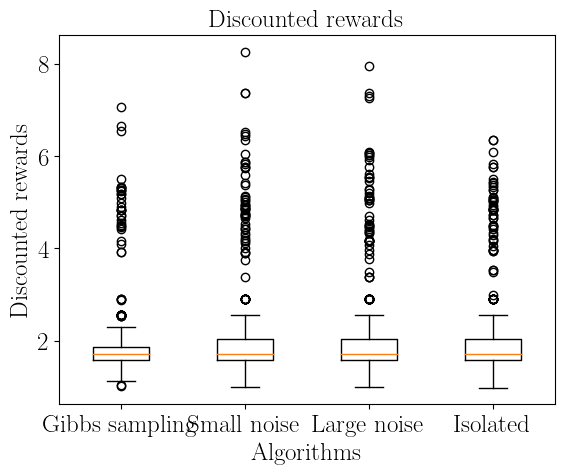

In [6]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Gibbs sampling', 'Small noise', 'Large noise', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

# plt.savefig("rewards.svg")
plt.title("Discounted rewards")
plt.show()

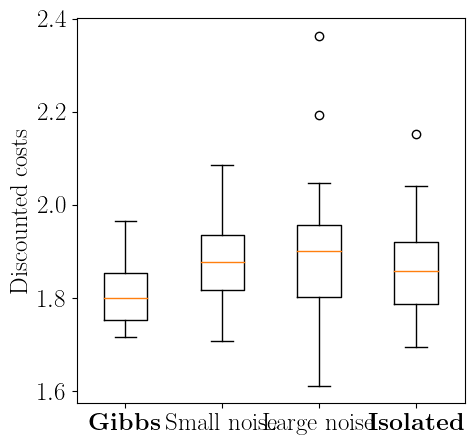

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.boxplot(sim_accu_total, labels=[r'\textbf{Gibbs}', 'Small noise', 'Large noise',  r'\textbf{Isolated}'])
# ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted costs")

# plt.savefig("rewards.svg")
# plt.title("Discounted rewards")
# plt.savefig("plot/reward.png")
# ax.set_xlabel("1")
# fig.savefig('plot/cost_plot.png')
plt.show()

In [8]:
N = len(df_data)
std_collab = np.std(collab_cost)
std_iso = np.std(iso_cost)
mu_collab = np.mean(collab_cost)
mu_iso = np.mean(iso_cost)
se = np.sqrt(std_collab**2 / N + std_iso**2 / N)
t_stat = (mu_iso - mu_collab) / se
t_stat

2.5248210075766773

In [9]:
t_crit_val = stats.t.ppf(0.975, 2*N-2)
t_crit_val

1.9607555832642807

In [12]:
# Setup parameters
start_idx = 0
limit = 5
t_list = range(start_idx, limit)

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

Text(0.1, 0.5, '$\\lvert \\mu_1^{(i)}-\\hat{\\mu}_1^{(i)} \\rvert$')

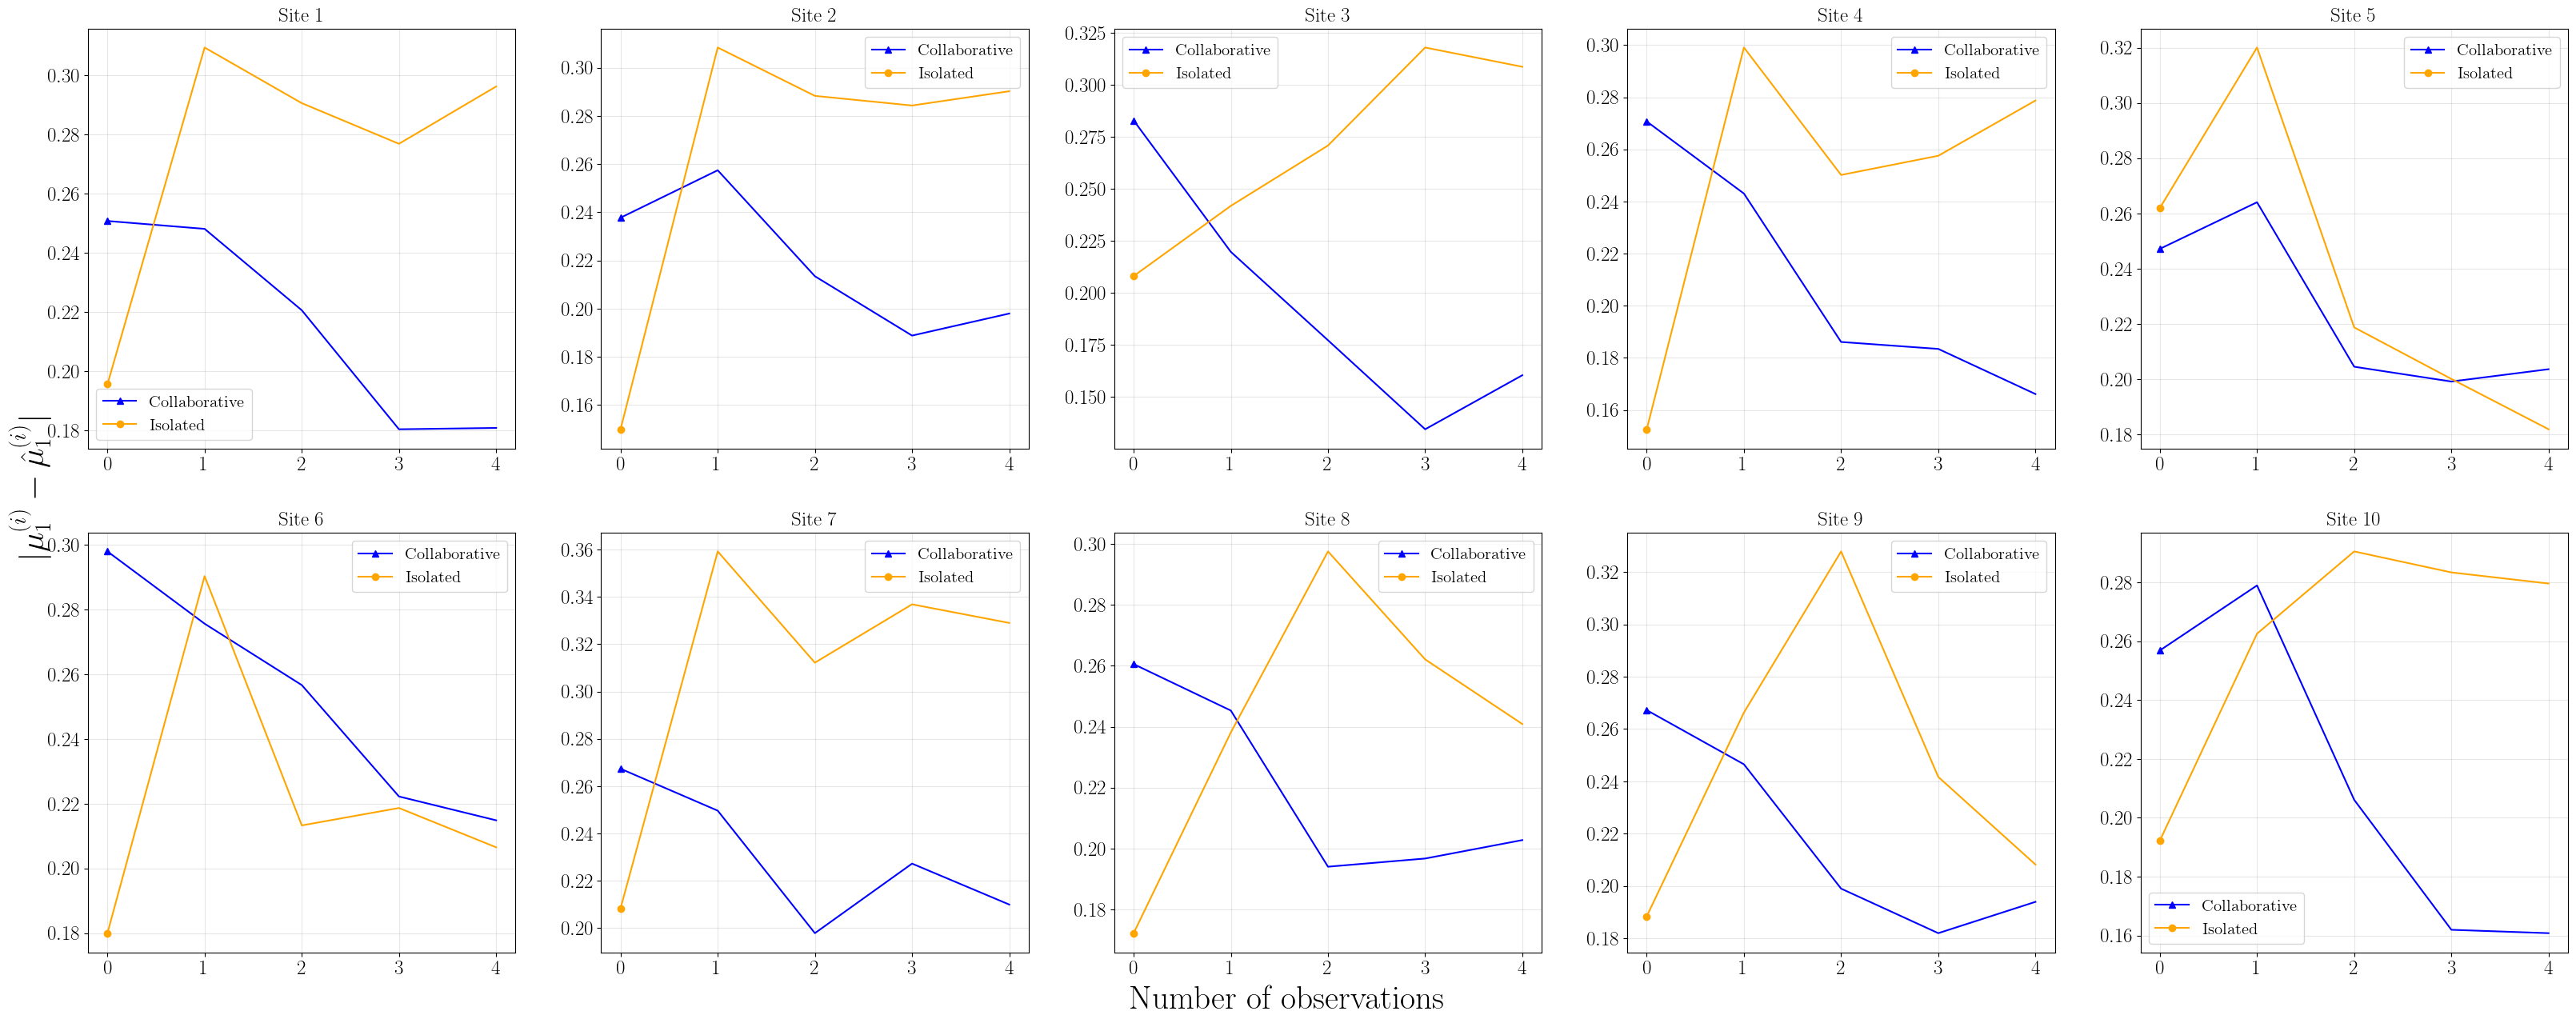

In [13]:
fig, ax = plt.subplots(2, 5, figsize=(40, 15))

# fig.supxlabel("Communication rounds")
# Plotting 10 sites
for i in range(10):        
    linear_line = collab_mu[start_idx:limit, i+10, 1]
#     linear_line_lap_1 = data[1][i, 0, start_idx:limit]
#     linear_line_lap_2 = data[2][i, 0, start_idx:limit]
    linear_line_iso = iso_mu[start_idx:limit, i+10, 1]
#     linear_line_ep = data[4][i, 0, start_idx:limit]

    ax[i // 5, i % 5].plot(t_list, linear_line, label="Collaborative", color='blue', marker='^', markevery=20)
#     ax[i // 5, i % 5].plot(t_list, linear_line_lap_1, label="Collaborative with noise = 1", color='green', marker='v', linestyle='--', markevery=20, alpha=0.5)
#     ax[i // 5, i % 5].plot(t_list, linear_line_lap_2, label="Collaborative with noise = 4", color='red', marker='s', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_iso, label="Isolated", color='orange', marker='o', markevery=20)
#     ax[i // 5, i % 5].plot(t_list, linear_line_ep, label="Expectation propagation", color='purple', marker='D', markevery=20)
    #     ax[i//5, i%5].fill_between(t_list, linear_line - linear_line_std, linear_line + linear_line_std, color='blue', alpha=0.1)
    ax[i // 5, i % 5].grid(visible=True, alpha=0.3)
#     ax[i // 5, i % 5].set_ylim([0.1, 1])
    ax[i // 5, i % 5].set_title(f'Site {i+1}')
    ax[i // 5, i % 5].legend()

ylabel = r'$\lvert \mu_1^{(i)}-\hat{\mu}_1^{(i)} \rvert$'
fig.text(0.5, 0.07, 'Number of observations', ha='center', va='center', fontsize=30)
fig.text(0.1, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)

## Policy

In [3]:
with open("simulation_results/50_5_12_0_collaborative_2025-01-05-04-00-15/result.json", 'r') as f:
    sim_collab_pol = json.load(f)

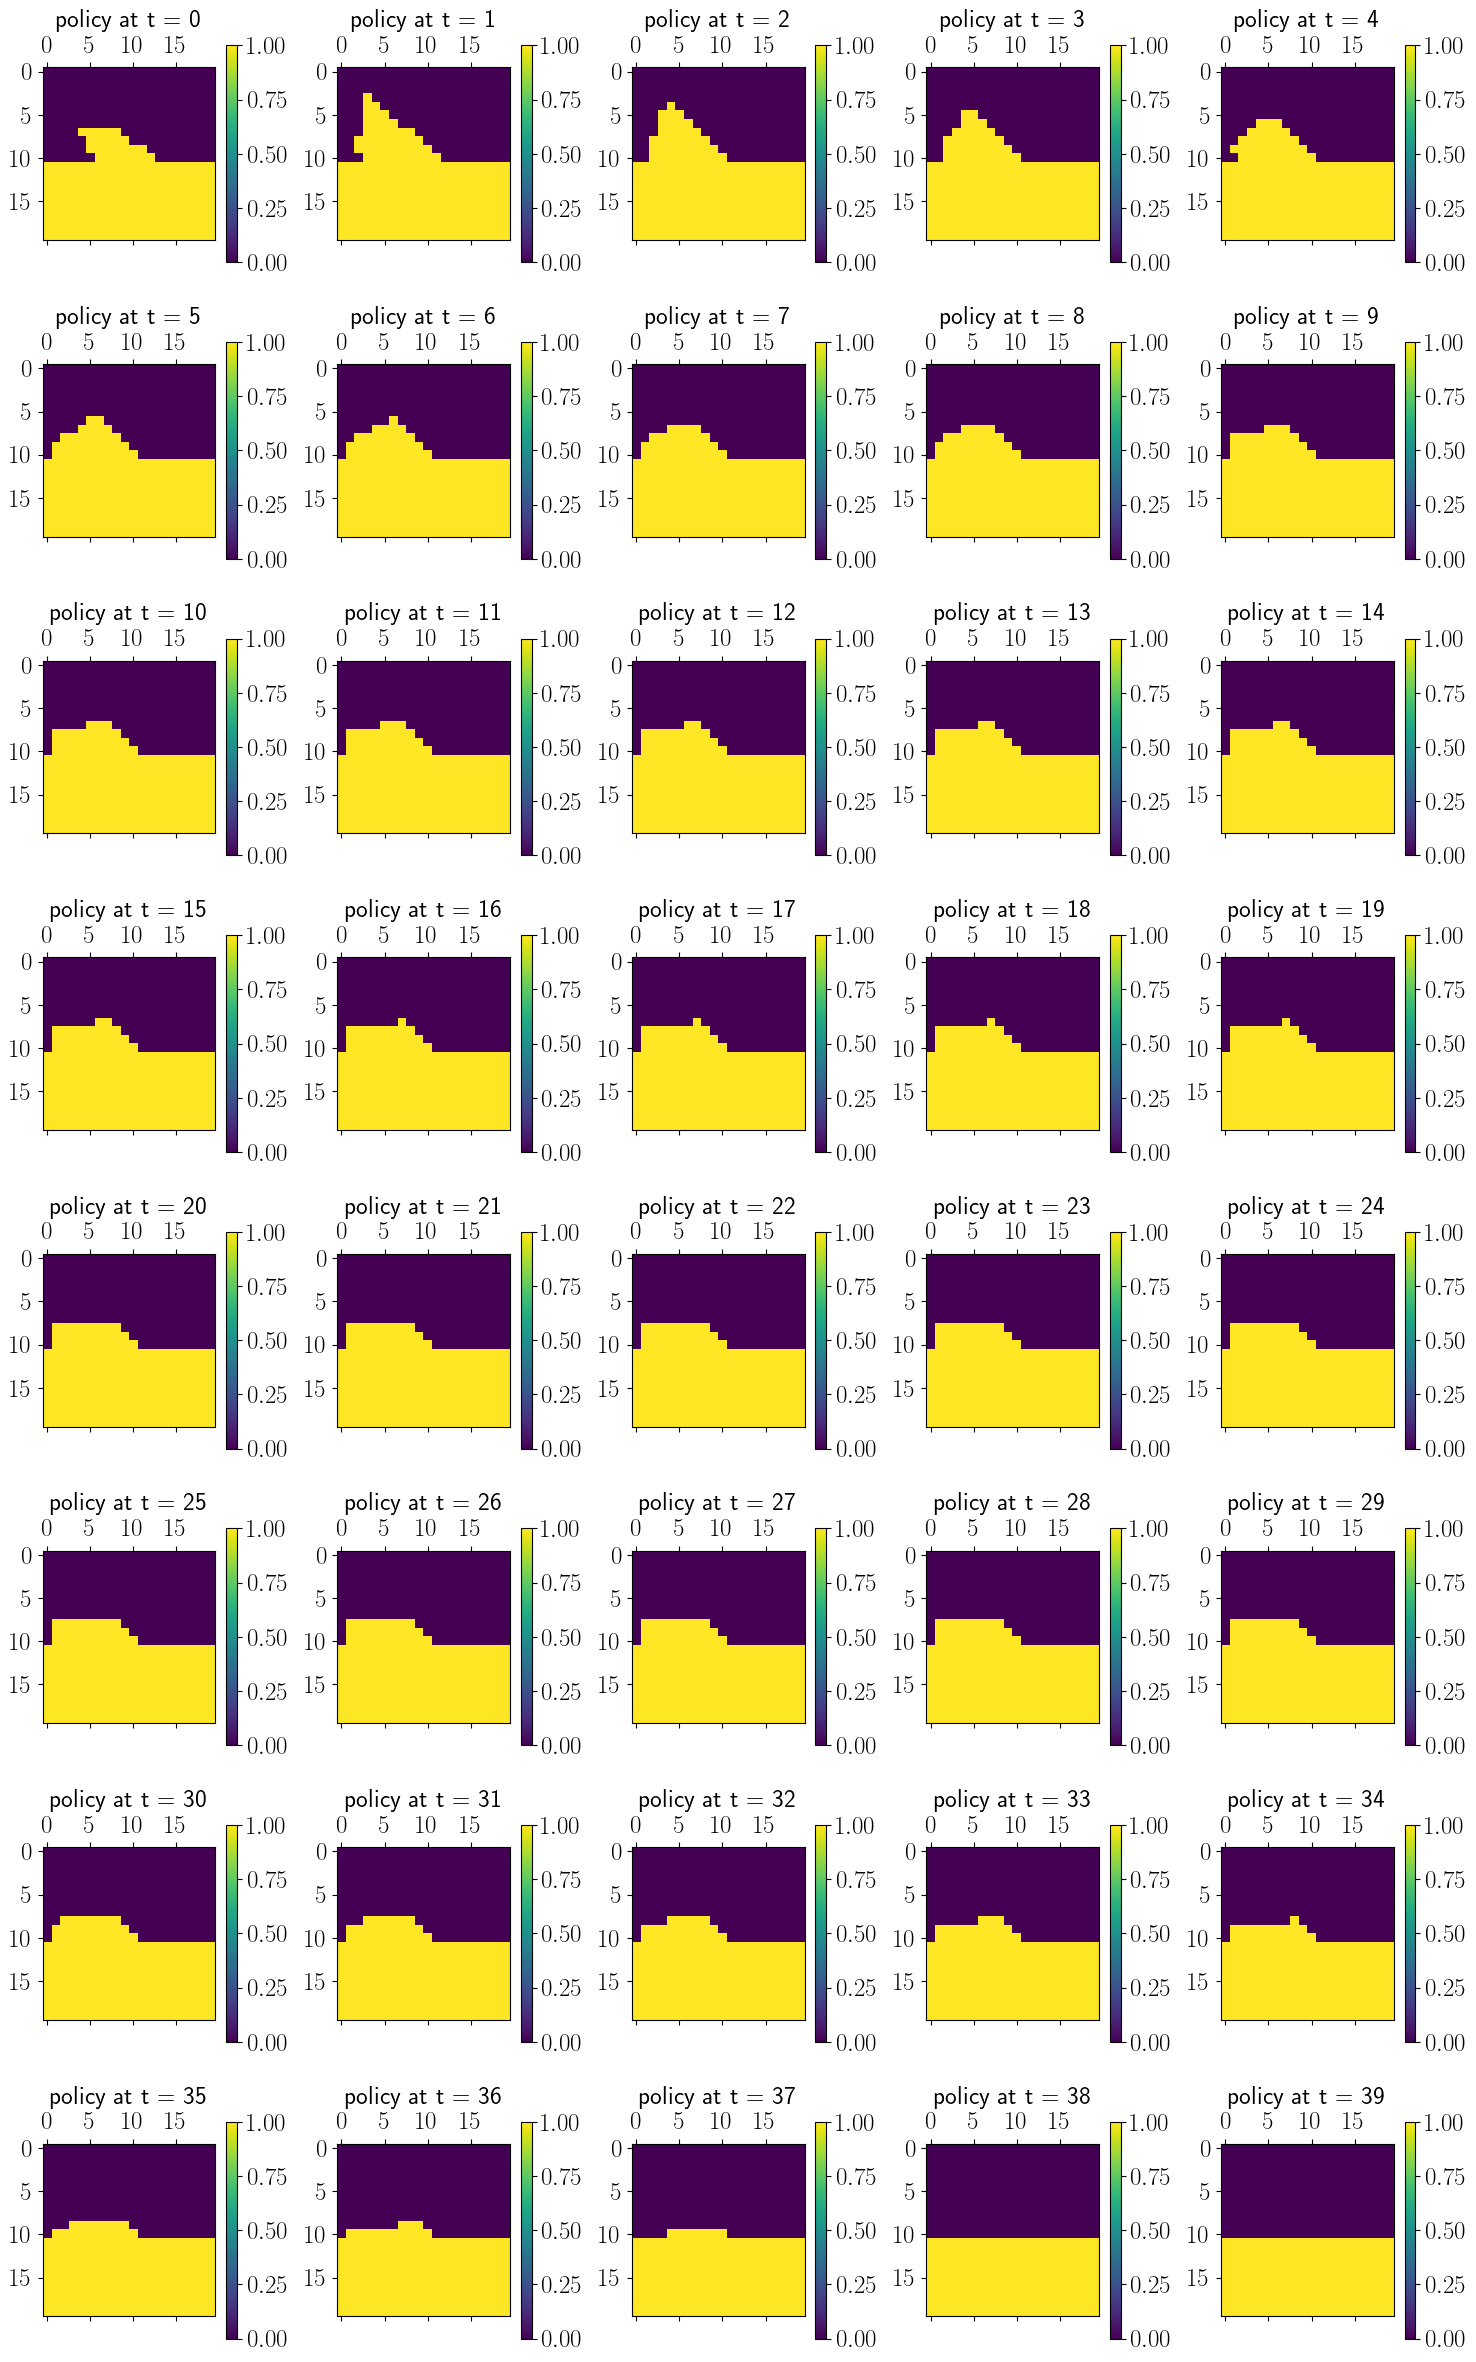

In [6]:
first_element = np.stack(sim_collab_pol[0]['policy'])[0]

# Determine the number of subplots (we have 40 matrices)
num_matrices = first_element.shape[0]
nrows = int(np.ceil(num_matrices / 5))  # Define number of rows (let's say we want 5 columns)
ncols = 5  # Number of columns

# Rotation options
rotation_degrees = 90  # Options: 90, 180, 270

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 3))

# Flatten the axes array for easy iteration and remove unused subplots
axes = axes.flatten()

# Loop over the second dimension
for i in range(num_matrices):
    # Reshape the last dimension to a (20, 20) matrix
    matrix = first_element[i].reshape(20, 20)[:, :]
    
    # Plot the matrix using matshow
    ax = axes[i]
    cax = ax.matshow(matrix, cmap='viridis')
    ax.set_title(f'policy at t = {i}')
    fig.colorbar(cax, ax=ax, orientation='vertical')

# Hide any unused subplots
for j in range(num_matrices, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()